In [122]:
import pandas as pd
import numpy as np
import os
import glob
import re
from pathlib import Path

In [123]:
# Load the 50 selected subjects
df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_master_merged_12-17-2025.csv')
print(f"Total sessions: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Total sessions: 4508

Columns: ['New_Path', 'Image Data ID', 'Subject', 'Group-RS:InitialDX', 'Sex', 'Age', 'Visit', 'Description', 'Acq Date', 'RS:DX_fill', 'DX2', 'RID', 'COLPROT', 'ORIGPROT', 'PTID', 'SITE', 'VISCODE', 'EXAMDATE_x', 'DX_bl', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'PTMARRY', 'APOE4', 'FDG', 'PIB', 'AV45', 'FBB', 'ABETA', 'TAU', 'PTAU', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'DX', 'mPACCdigit', 'mPACCtrailsB', 'EXAMDATE_bl', 'CDRSB_bl', 'ADAS11_bl', 'ADAS13_bl', 'ADASQ4_bl', 'MMSE_bl',

/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_51193/947175501.py:2: DtypeWarning: Columns (31,32,116,117) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_master_merged_12-17-2025.csv')


,New_Path,Image Data ID,Subject,Group-RS:InitialDX,Sex,Age,Visit,Description,Acq Date,RS:DX_fill,...,update_stamp_y,PHASE_y,VISCODE2_y,EXAMDATE_y,ADNI_MEM,ADNI_EF,ADNI_LAN,ADNI_VS,ADNI_EF2,update_stamp
0,082_S_1256_2007-02-16_S26812_I63155_warped_bra...,63155,082_S_1256,CN,F,72,sc,MPR; GradWarp; B1 Correction; N3; Scaled,2/16/07,CN,...,2007-03-07 00:00:00,ADNI1,bl,2007-02-23,1.512,0.678,2.315,0.739,0.251,2023-12-11 14:53:52
1,082_S_1256_2007-10-11_S41304_I80379_warped_bra...,80379,082_S_1256,CN,F,72,m06,MPR; GradWarp; B1 Correction; N3; Scaled,10/11/07,CN,...,2007-10-05 00:00:00,ADNI1,m06,2007-10-04,1.700,0.859,2.807,-0.080,0.434,2023-12-11 14:53:52
2,082_S_1256_2008-05-29_S50835_I108578_warped_br...,108578,082_S_1256,CN,F,73,m12,MPR; GradWarp; B1 Correction; N3; Scaled,5/29/08,CN,...,2008-03-04 00:00:00,ADNI1,m12,2008-03-03,1.695,1.236,2.315,0.739,0.893,2023-12-11 14:53:52
3,082_S_1256_2009-03-18_S22511_I436819_warped_br...,436819,082_S_1256,CN,F,73,m24,MT1; GradWarp; N3m,3/18/09,CN,...,2009-03-18 00:00:00,ADNI1,m24,2009-03-18,2.546,0.910,2.189,0.739,0.402,2023-12-11 14:53:52
4,082_S_1256_2011-04-21_S10506_I296808_warped_br...,296808,082_S_1256,CN,F,76,v06,MT1; GradWarp; N3m,4/21/11,CN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
# Define the folders to search
base_path = '/Users/othree/Cognitive Reserve Modeling/Data'
folders = [
    'ADNI_Download',
    'ADNI_Download 2',
    'ADNI_Download 3',
    'ADNI_Download 4',
    'ADNI_Download 5',
    'ADNI_Download 6',
    'ADNI_Download 7'
]

# Collect all MRI files from all folders
all_files = []
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.exists(folder_path):
        files = glob.glob(os.path.join(folder_path, '*.nii.gz'))
        all_files.extend(files)
        print(f"{folder}: {len(files)} files")

print(f"\nTotal MRI files found: {len(all_files)}")

ADNI_Download: 300 files
ADNI_Download 2: 304 files
ADNI_Download 3: 302 files
ADNI_Download 4: 303 files
ADNI_Download 5: 303 files
ADNI_Download 6: 304 files
ADNI_Download 7: 125 files

Total MRI files found: 1941


In [125]:
# Parse filenames to extract S#####_I###### pattern
# Format: cropped_?_?_?_date_S#####_I######_orig-in-mni?.nii.gz
# Example: cropped_033_S_0889_2006-09-25_S19296_I51629_orig-in-mni305.nii.gz

file_info = []
for filepath in all_files:
    filename = os.path.basename(filepath)
    
    # Extract S#####_I###### pattern using regex
    pattern = r'(S\d+)_(I\d+)'
    match = re.search(pattern, filename)
    
    if match:
        s_id = match.group(1)
        i_id = match.group(2)
        si_pattern = f"{s_id}_{i_id}"
    else:
        s_id = None
        i_id = None
        si_pattern = None
    
    file_info.append({
        'filepath': filepath,
        'filename': filename,
        's_id': s_id,
        'i_id': i_id,
        'si_pattern': si_pattern
    })

file_df = pd.DataFrame(file_info)
print(f"Parsed {len(file_df)} files")
print(f"\nSample parsed files:")
file_df.head(10)

Parsed 1941 files

Sample parsed files:


,filepath,filename,s_id,i_id,si_pattern
0,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_035_S_0341_2008-04-24_S49286_I105351_o...,S49286,I105351,S49286_I105351
1,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_041_S_1002_2007-06-07_S33248_I71615_or...,S33248,I71615,S33248_I71615
2,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_035_S_0204_2009-03-05_S68199_I151107_o...,S68199,I151107,S68199_I151107
3,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_036_S_0869_2009-11-11_S76486_I163163_o...,S76486,I163163,S76486_I163163
4,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_037_S_0327_2007-05-25_S32632_I72204_or...,S32632,I72204,S32632_I72204
5,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_036_S_0869_2006-10-30_S21421_I36993_or...,S21421,I36993,S21421_I36993
6,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_035_S_0341_2006-04-06_S12952_I45213_or...,S12952,I45213,S12952_I45213
7,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_041_S_1260_2009-03-04_S64117_I142068_o...,S64117,I142068,S64117_I142068
8,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_035_S_0048_2005-11-22_S10257_I45183_or...,S10257,I45183,S10257_I45183
9,/Users/othree/Cognitive Reserve Modeling/Data/...,cropped_037_S_0454_2006-12-20_S24345_I90558_or...,S24345,I90558,S24345_I90558


In [126]:
# Match files using S#####_I###### pattern from New_Path column
# New_Path example: 126_S_4686_2013-05-07_S18882_I371905_warped_brain.nii.gz

df['si_pattern'] = None
df['matched_filepath'] = None

# Extract S#####_I###### pattern from New_Path column
for idx, row in df.iterrows():
    new_path = row['New_Path']
    
    # Extract S#####_I###### pattern from new_path
    pattern = r'(S\d+)_(I\d+)'
    match = re.search(pattern, new_path)
    
    if match:
        s_id = match.group(1)
        i_id = match.group(2)
        si_pattern = f"{s_id}_{i_id}"
        df.at[idx, 'si_pattern'] = si_pattern

print(f"Extracted S#####_I###### patterns from {df['si_pattern'].notna().sum()} rows")
print(f"\nSample patterns from df:")
print(df[['New_Path', 'si_pattern']].head())

# Match with file_df
matched_count = 0
for idx, row in df.iterrows():
    si_pattern = row['si_pattern']
    
    if pd.notna(si_pattern):
        # Find matching file
        match = file_df[file_df['si_pattern'] == si_pattern]
        
        if len(match) > 0:
            df.at[idx, 'matched_filepath'] = match.iloc[0]['filepath']
            matched_count += 1

print(f"\nMatched {matched_count} out of {len(df)} sessions")
print(f"Unmatched sessions: {len(df) - matched_count}")

Extracted S#####_I###### patterns from 4487 rows

Sample patterns from df:
                                            New_Path      si_pattern
0  082_S_1256_2007-02-16_S26812_I63155_warped_bra...   S26812_I63155
1  082_S_1256_2007-10-11_S41304_I80379_warped_bra...   S41304_I80379
2  082_S_1256_2008-05-29_S50835_I108578_warped_br...  S50835_I108578
3  082_S_1256_2009-03-18_S22511_I436819_warped_br...  S22511_I436819
4  082_S_1256_2011-04-21_S10506_I296808_warped_br...  S10506_I296808

Matched 1572 out of 4508 sessions
Unmatched sessions: 2936


In [127]:
# Show matched results
print("Matched sessions:")
df[df['matched_filepath'].notna()][['Subject', 'DX', 'si_pattern', 'matched_filepath']].head(10)

Matched sessions:


,Subject,DX,si_pattern,matched_filepath
34,094_S_0434,MCI,S13570_I39122,/Users/othree/Cognitive Reserve Modeling/Data/...
35,094_S_0434,Dementia,S22339_I39190,/Users/othree/Cognitive Reserve Modeling/Data/...
36,094_S_0434,Dementia,S32094_I65730,/Users/othree/Cognitive Reserve Modeling/Data/...
37,094_S_0434,Dementia,S42495_I85589,/Users/othree/Cognitive Reserve Modeling/Data/...
38,094_S_0434,Dementia,S50352_I107717,/Users/othree/Cognitive Reserve Modeling/Data/...
41,094_S_0526,CN,S14559_I63468,/Users/othree/Cognitive Reserve Modeling/Data/...
42,094_S_0526,CN,S27499_I64346,/Users/othree/Cognitive Reserve Modeling/Data/...
43,094_S_0526,CN,S32908_I80713,/Users/othree/Cognitive Reserve Modeling/Data/...
44,094_S_0526,CN,S52009_I121461,/Users/othree/Cognitive Reserve Modeling/Data/...
52,094_S_0711,CN,S16553_I39137,/Users/othree/Cognitive Reserve Modeling/Data/...


In [128]:
# Show unmatched sessions for debugging
unmatched = df[df['matched_filepath'].isna()]
if len(unmatched) > 0:
    print(f"Unmatched sessions: {len(unmatched)}")
    print(unmatched[['Subject', 'DX', 'si_pattern', 'New_Path']])
else:
    print("All sessions matched successfully!")

Unmatched sessions: 2936
         Subject        DX      si_pattern  \
0     082_S_1256        CN   S26812_I63155   
1     082_S_1256        CN   S41304_I80379   
2     082_S_1256        CN  S50835_I108578   
3     082_S_1256        CN  S22511_I436819   
4     082_S_1256        CN  S10506_I296808   
...          ...       ...             ...   
4503  082_S_1079  Dementia   S22650_I49490   
4504  082_S_1079  Dementia   S46012_I99086   
4505  082_S_1119       MCI   S23733_I63147   
4506  082_S_1119       MCI   S44687_I91873   
4507  082_S_1119       MCI  S56158_I123244   

                                               New_Path  
0     082_S_1256_2007-02-16_S26812_I63155_warped_bra...  
1     082_S_1256_2007-10-11_S41304_I80379_warped_bra...  
2     082_S_1256_2008-05-29_S50835_I108578_warped_br...  
3     082_S_1256_2009-03-18_S22511_I436819_warped_br...  
4     082_S_1256_2011-04-21_S10506_I296808_warped_br...  
...                                                 ...  
4503  082_S_1079

In [129]:
# # Save the matched dataframe
# output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_selected_50subjects_matched.csv'
# df.to_csv(output_path, index=False)
# print(f"Saved matched data to: {output_path}")

In [130]:
# Install nibabel for reading NIfTI files
# !pip install nibabel

In [131]:
print(f"Total matched sessions: {df['matched_filepath'].notna().sum()}")
print(f"Total sessions: {len(df)}")

# Filter only matched sessions
matched_df = df[df['matched_filepath'].notna()].copy()

print(f"\nMatched sessions by diagnosis:")
print(matched_df['DX'].value_counts())

# Select 50 unique subjects: AD 17, MCI 17, CN 16
np.random.seed(42)

selected_data = []
selected_subjects = set()

# Dementia (AD) - 17 subjects
ad_data = matched_df[matched_df['DX'] == 'Dementia']
ad_subjects = ad_data['Subject'].unique()
print(f"\nAvailable AD subjects: {len(ad_subjects)}")

if len(ad_subjects) >= 17:
    selected_ad_subjects = np.random.choice(ad_subjects, size=17, replace=False)
    for subject in selected_ad_subjects:
        subject_data = ad_data[ad_data['Subject'] == subject]
        random_session = subject_data.sample(n=1)
        selected_data.append(random_session)
        selected_subjects.add(subject)
else:
    print(f"Warning: Not enough AD subjects. Only {len(ad_subjects)} available.")
    for subject in ad_subjects:
        subject_data = ad_data[ad_data['Subject'] == subject]
        random_session = subject_data.sample(n=1)
        selected_data.append(random_session)
        selected_subjects.add(subject)

# MCI - 17 subjects (excluding already selected subjects)
mci_data = matched_df[matched_df['DX'] == 'MCI']
mci_subjects = [s for s in mci_data['Subject'].unique() if s not in selected_subjects]
print(f"Available MCI subjects (excluding already selected): {len(mci_subjects)}")

if len(mci_subjects) >= 17:
    selected_mci_subjects = np.random.choice(mci_subjects, size=17, replace=False)
    for subject in selected_mci_subjects:
        subject_data = mci_data[mci_data['Subject'] == subject]
        random_session = subject_data.sample(n=1)
        selected_data.append(random_session)
        selected_subjects.add(subject)
else:
    print(f"Warning: Not enough MCI subjects. Only {len(mci_subjects)} available.")
    for subject in mci_subjects:
        subject_data = mci_data[mci_data['Subject'] == subject]
        random_session = subject_data.sample(n=1)
        selected_data.append(random_session)
        selected_subjects.add(subject)

# CN - 16 subjects (excluding already selected subjects)
cn_data = matched_df[matched_df['DX'] == 'CN']
cn_subjects = [s for s in cn_data['Subject'].unique() if s not in selected_subjects]
print(f"Available CN subjects (excluding already selected): {len(cn_subjects)}")

if len(cn_subjects) >= 16:
    selected_cn_subjects = np.random.choice(cn_subjects, size=16, replace=False)
    for subject in selected_cn_subjects:
        subject_data = cn_data[cn_data['Subject'] == subject]
        random_session = subject_data.sample(n=1)
        selected_data.append(random_session)
        selected_subjects.add(subject)
else:
    print(f"Warning: Not enough CN subjects. Only {len(cn_subjects)} available.")
    for subject in cn_subjects:
        subject_data = cn_data[cn_data['Subject'] == subject]
        random_session = subject_data.sample(n=1)
        selected_data.append(random_session)
        selected_subjects.add(subject)

# Create final dataframe
final_df = pd.concat(selected_data, ignore_index=True)

print(f"\nFinal selection:")
print(f"Total rows: {len(final_df)}")
print(f"Unique subjects: {final_df['Subject'].nunique()}")
print(f"\nDiagnosis distribution:")
print(final_df['DX'].value_counts())

# Verify all have matched filepaths
print(f"\nAll matched: {final_df['matched_filepath'].notna().all()}")

# # Save to CSV
# output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_final_50subjects_matched.csv'
# final_df.to_csv(output_path, index=False)
# print(f"\nSaved to: {output_path}")


Total matched sessions: 1572
Total sessions: 4508

Matched sessions by diagnosis:
DX
MCI         588
CN          509
Dementia    475
Name: count, dtype: int64

Available AD subjects: 145
Available MCI subjects (excluding already selected): 146
Available CN subjects (excluding already selected): 134

Final selection:
Total rows: 50
Unique subjects: 50

Diagnosis distribution:
DX
Dementia    17
MCI         17
CN          16
Name: count, dtype: int64

All matched: True


In [132]:
# Load and visualize selected MRI images
import nibabel as nib
import matplotlib.pyplot as plt

print(f"Total subjects to visualize: {len(final_df)}")
print(f"\nImage sizes:")

# Check sizes of all images
for idx, row in final_df.iterrows():
    filepath = row['matched_filepath']
    subject = row['Subject']
    dx = row['DX']
    
    if pd.notna(filepath) and os.path.exists(filepath):
        img = nib.load(filepath)
        shape = img.shape
        print(f"{idx+1}. {subject} ({dx}): {shape} - {os.path.basename(filepath)}")
    else:
        print(f"{idx+1}. {subject} ({dx}): FILE NOT FOUND - {filepath}")

Total subjects to visualize: 50

Image sizes:
1. 014_S_0658 (Dementia): (173, 199, 215) - cropped_014_S_0658_2007-07-30_S36601_I73041_orig-in-mni305.nii.gz
2. 062_S_0793 (Dementia): (173, 199, 215) - cropped_062_S_0793_2007-02-27_S27205_I50533_orig-in-mni305.nii.gz
3. 127_S_0431 (Dementia): (173, 199, 215) - cropped_127_S_0431_2007-01-04_S24680_I63601_orig-in-mni305.nii.gz
4. 123_S_0094 (Dementia): (173, 199, 215) - cropped_123_S_0094_2007-01-10_S24976_I119306_orig-in-mni305.nii.gz
5. 137_S_1041 (Dementia): (173, 199, 215) - cropped_137_S_1041_2007-06-06_S33081_I86630_orig-in-mni305.nii.gz
6. 035_S_0204 (Dementia): (173, 199, 215) - cropped_035_S_0204_2008-03-06_S46711_I99196_orig-in-mni305.nii.gz
7. 041_S_1368 (Dementia): (173, 199, 215) - cropped_041_S_1368_2007-11-29_S43147_I86819_orig-in-mni305.nii.gz
8. 033_S_0724 (Dementia): (173, 199, 215) - cropped_033_S_0724_2007-02-05_S26114_I54731_orig-in-mni305.nii.gz
9. 023_S_0139 (Dementia): (173, 199, 215) - cropped_023_S_0139_2007-02-09

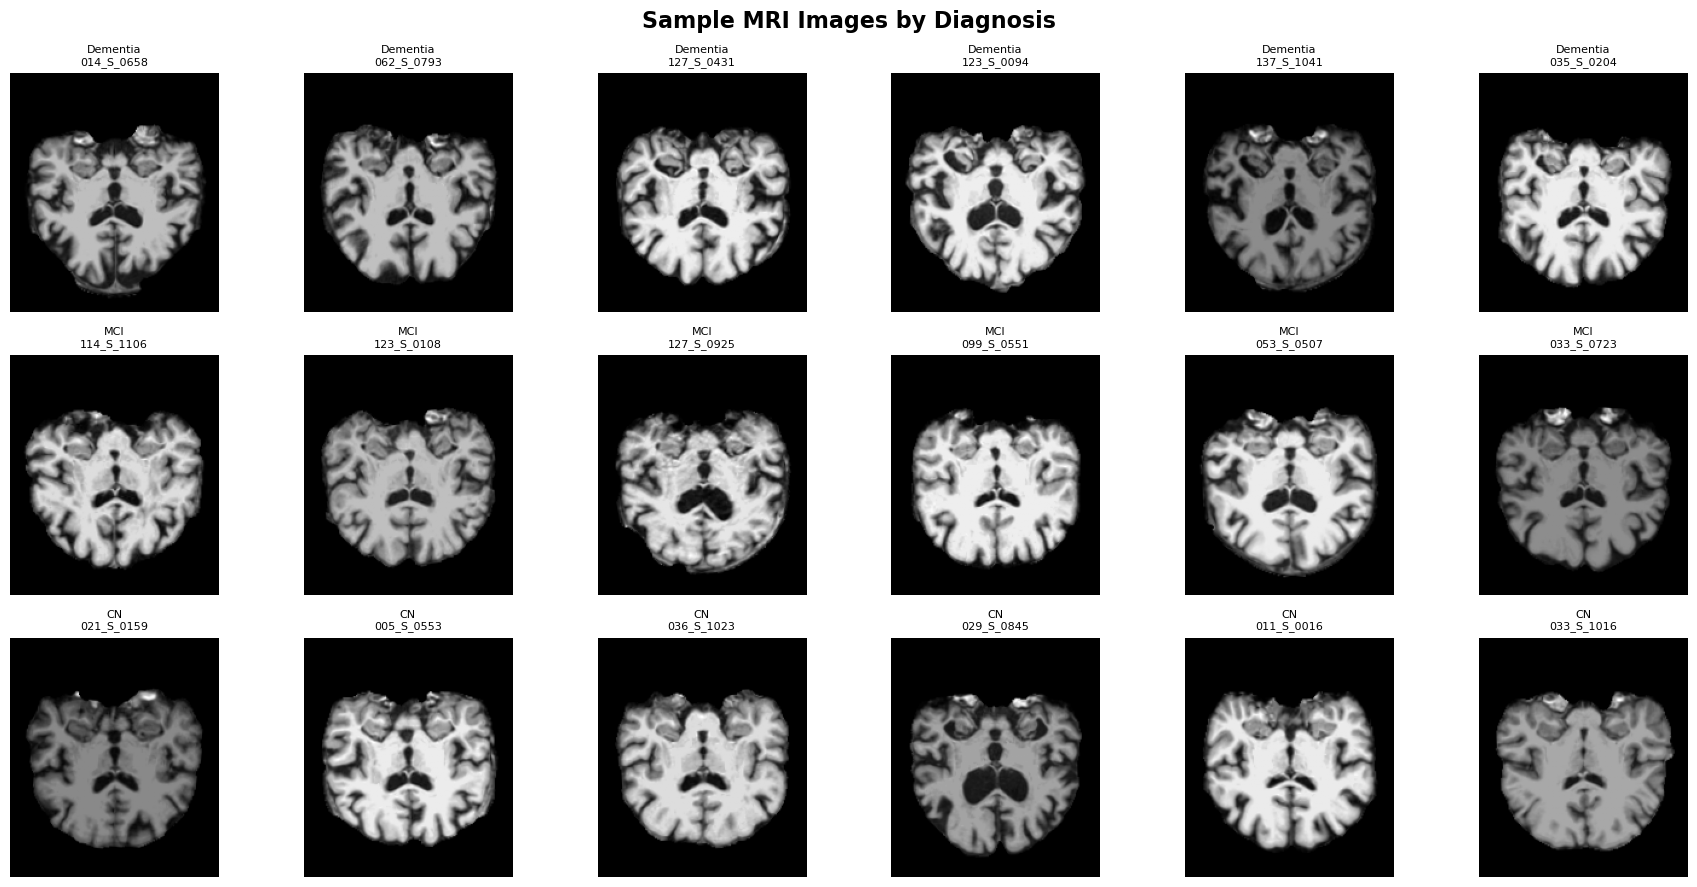

In [133]:
# Visualize sample images from each diagnosis group
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample MRI Images by Diagnosis', fontsize=16, fontweight='bold')

# Select 6 samples from each group
for group_idx, dx_group in enumerate(['Dementia', 'MCI', 'CN']):
    group_data = final_df[final_df['DX'] == dx_group].head(6)
    
    for img_idx, (idx, row) in enumerate(group_data.iterrows()):
        filepath = row['matched_filepath']
        subject = row['Subject']
        
        if pd.notna(filepath) and os.path.exists(filepath):
            img = nib.load(filepath)
            img_data = img.get_fdata()
            
            # Show middle slice
            mid_slice = img_data.shape[2] // 2
            slice_data = img_data[:, :, mid_slice]
            
            ax = axes[group_idx, img_idx]
            ax.imshow(slice_data.T, cmap='gray', origin='lower')
            ax.set_title(f'{dx_group}\n{subject}', fontsize=8)
            ax.axis('off')
        else:
            ax = axes[group_idx, img_idx]
            ax.text(0.5, 0.5, 'Not Found', ha='center', va='center')
            ax.axis('off')

plt.tight_layout()
plt.show()

In [134]:
# Split data into Train (40) and Val (10: CN 3, MCI 4, Dementia 3)
import pandas as pd
import numpy as np

final_df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_final_50subjects_matched.csv')

np.random.seed(42)

# Separate by diagnosis
cn_data = final_df[final_df['DX'] == 'CN'].copy()
mci_data = final_df[final_df['DX'] == 'MCI'].copy()
dementia_data = final_df[final_df['DX'] == 'Dementia'].copy()

print(f"Total - CN: {len(cn_data)}, MCI: {len(mci_data)}, Dementia: {len(dementia_data)}")

# Val split - keep original indices
val_cn_indices = cn_data.sample(n=3, random_state=42).index
val_mci_indices = mci_data.sample(n=4, random_state=42).index
val_dementia_indices = dementia_data.sample(n=3, random_state=42).index

val_indices = list(val_cn_indices) + list(val_mci_indices) + list(val_dementia_indices)
val_df = final_df.loc[val_indices].copy()

# Train split (remaining)
train_indices = [idx for idx in final_df.index if idx not in val_indices]
train_df = final_df.loc[train_indices].copy()

print(f"\nTrain: {len(train_df)}")
print(train_df['DX'].value_counts())
print(f"\nVal: {len(val_df)}")
print(val_df['DX'].value_counts())

# Verify total
print(f"\nTotal check: {len(train_df) + len(val_df)} (should be 50)")
print(f"Expected Train counts: Dementia=14, MCI=13, CN=13")

Total - CN: 16, MCI: 17, Dementia: 17

Train: 40
DX
Dementia    14
MCI         13
CN          13
Name: count, dtype: int64

Val: 10
DX
MCI         4
CN          3
Dementia    3
Name: count, dtype: int64

Total check: 50 (should be 50)
Expected Train counts: Dementia=14, MCI=13, CN=13


In [135]:
# Create TSV files for the CNN model
def create_tsv_file(df, output_path):
    # Create TSV format matching the original
    tsv_data = []
    
    for idx, row in df.iterrows():
        # Map diagnosis: Dementia -> AD
        diagnosis = row['DX']
        if diagnosis == 'Dementia':
            diagnosis = 'AD'
        
        # Create participant_id from Subject
        participant_id = f"sub-ADNI{row['Subject'].replace('_', '')}"
        
        # Create session_id (use M00 as default)
        session_id = "ses-M00"
        
        # Get age (if available, otherwise use default)
        age = row.get('AGE', 75.0) if 'AGE' in row else 75.0
        age_rounded = round(age * 2) / 2  # Round to nearest 0.5
        
        # Get MMSE if available
        mmse = row.get('MMSE', 28.0) if 'MMSE' in row else 28.0
        
        tsv_data.append({
            'participant_id': participant_id,
            'session_id': session_id,
            'diagnosis': diagnosis,
            'mmse': mmse,
            'cdr': 0.0,
            'cdr_sb': 0.0,
            'age': age,
            'examination_date': '2024-01-01',
            'earliest_time': '2024-01-01',
            'age_rounded': age_rounded,
            'filepath': row['matched_filepath'],
            'original_subject': row['Subject']
        })
    
    tsv_df = pd.DataFrame(tsv_data)
    tsv_df.to_csv(output_path, sep='\t', index=False)
    print(f"Saved TSV to: {output_path}")
    return tsv_df

# Create Train and Val TSV files
train_tsv = create_tsv_file(train_df, 
    '/Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master/datasets/files/Train_diagnosis_ADNI_custom.tsv')
val_tsv = create_tsv_file(val_df,
    '/Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master/datasets/files/Val_diagnosis_ADNI_custom.tsv')

print("\nTrain TSV:")
print(train_tsv.head())
print("\nVal TSV:")
print(val_tsv.head())

Saved TSV to: /Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master/datasets/files/Train_diagnosis_ADNI_custom.tsv
Saved TSV to: /Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master/datasets/files/Val_diagnosis_ADNI_custom.tsv

Train TSV:
     participant_id session_id diagnosis  mmse  cdr  cdr_sb   age  \
0  sub-ADNI127S0431    ses-M00        AD  19.0  0.0     0.0  84.0   
1  sub-ADNI123S0094    ses-M00        AD  19.0  0.0     0.0  70.7   
2  sub-ADNI137S1041    ses-M00        AD  17.0  0.0     0.0  70.9   
3  sub-ADNI041S1368    ses-M00        AD  15.0  0.0     0.0  75.2   
4  sub-ADNI033S0724    ses-M00        AD  25.0  0.0     0.0  78.6   

  examination_date earliest_time  age_rounded  \
0       2024-01-01    2024-01-01         84.0   
1       2024-01-01    2024-01-01         70.5   
2       2024-01-01    2024-01-01         71.0   
3       2024-01-01    2024-01-01         75.0   
4       2024-01-01    2024-01-01         78.5   

                          

In [136]:
# Check image sizes to ensure they are compatible with CNN model (needs >= 96x96x96)
import nibabel as nib

print("Checking image sizes...")
print("="*60)

size_issues = []
for idx, row in final_df.iterrows():
    filepath = row['matched_filepath']
    subject = row['Subject']
    dx = row['DX']
    
    if pd.notna(filepath) and os.path.exists(filepath):
        img = nib.load(filepath)
        shape = img.shape
        
        # Check if image is large enough for 96x96x96 crop
        is_ok = all(s >= 96 for s in shape)
        status = "OK" if is_ok else "TOO SMALL"
        
        print(f"{subject} ({dx}): {shape} - {status}")
        
        if not is_ok:
            size_issues.append({
                'subject': subject,
                'dx': dx,
                'shape': shape,
                'filepath': filepath
            })

if size_issues:
    print(f"\n{'='*60}")
    print(f"WARNING: {len(size_issues)} images are too small for 96x96x96 crop!")
    print("These images need to be resized or padding applied.")
else:
    print(f"\n{'='*60}")
    print("All images are compatible with the CNN model (>= 96x96x96)!")

Checking image sizes...
014_S_0658 (Dementia): (173, 199, 215) - OK
062_S_0793 (Dementia): (173, 199, 215) - OK
127_S_0431 (Dementia): (173, 199, 215) - OK
123_S_0094 (Dementia): (173, 199, 215) - OK
137_S_1041 (Dementia): (173, 199, 215) - OK
035_S_0204 (Dementia): (173, 199, 215) - OK
041_S_1368 (Dementia): (173, 199, 215) - OK
033_S_0724 (Dementia): (173, 199, 215) - OK
023_S_0139 (Dementia): (173, 199, 215) - OK
123_S_0091 (Dementia): (173, 199, 215) - OK
116_S_0392 (Dementia): (173, 199, 215) - OK
007_S_0128 (Dementia): (173, 199, 215) - OK
052_S_0952 (Dementia): (173, 199, 215) - OK
022_S_0129 (Dementia): (173, 199, 215) - OK
016_S_1326 (Dementia): (173, 199, 215) - OK
136_S_0300 (Dementia): (173, 199, 215) - OK
033_S_0922 (Dementia): (173, 199, 215) - OK
116_S_0361 (MCI): (173, 199, 215) - OK
007_S_0128 (MCI): (173, 199, 215) - OK
036_S_0945 (MCI): (173, 199, 215) - OK
023_S_0887 (MCI): (173, 199, 215) - OK
007_S_0698 (MCI): (173, 199, 215) - OK
099_S_0551 (MCI): (173, 199, 215)

In [137]:
# Verify TSV files were created correctly
import os

tsv_dir = '/Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master/datasets/files'

train_tsv_path = os.path.join(tsv_dir, 'Train_diagnosis_ADNI_custom.tsv')
val_tsv_path = os.path.join(tsv_dir, 'Val_diagnosis_ADNI_custom.tsv')

print("Checking TSV files...")
print("="*60)

if os.path.exists(train_tsv_path):
    train_check = pd.read_csv(train_tsv_path, sep='\t')
    print(f"✓ Train TSV exists: {len(train_check)} rows")
    print(f"  Diagnosis counts: {train_check['diagnosis'].value_counts().to_dict()}")
else:
    print(f"✗ Train TSV not found at {train_tsv_path}")

if os.path.exists(val_tsv_path):
    val_check = pd.read_csv(val_tsv_path, sep='\t')
    print(f"\n✓ Val TSV exists: {len(val_check)} rows")
    print(f"  Diagnosis counts: {val_check['diagnosis'].value_counts().to_dict()}")
else:
    print(f"✗ Val TSV not found at {val_tsv_path}")

print("\n" + "="*60)
print("Ready to train! Run the following command in terminal:")
print("cd '/Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master'")
print("python main_custom.py")

Checking TSV files...
✓ Train TSV exists: 40 rows
  Diagnosis counts: {'AD': 14, 'MCI': 13, 'CN': 13}

✓ Val TSV exists: 10 rows
  Diagnosis counts: {'MCI': 4, 'CN': 3, 'AD': 3}

Ready to train! Run the following command in terminal:
cd '/Users/othree/Cognitive Reserve Modeling/CNN_design_for_AD-master'
python main_custom.py
